### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

from src.activation_recorder import MultiPromptActivations
from src.time_series_activations import MultiPromptTimeSeries
from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries


paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_activations_file: ${paths.data_activations_dir}multi_prompt_activations.pkl
  data_phyid_dir: ${paths.data_dir}phyid/${paths.phyid_method}
  data_phyid_file: ${paths.data_phyid_dir}multi_prompt_phyid.pkl
  data_phyid_file_data_array: ${paths.data_phyid_dir}multi_prompt_phyid.nc
  plot_dir: ${paths.project_root}plots/${paths.model_path}${generation.name}/
  plot_time_series_dir: ${paths.plot_dir}time_series/${paths.activation_method}
  plot_phyid_dir: ${path

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Time Series Loading

In [2]:
data_activations_file = cfg.paths.data_activations_file
activations = MultiPromptActivations.load(file_path=data_activations_file)

MultiPromptActivations successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/activations/multi_prompt_activations.pkl'.


In [3]:
time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    node_type=cfg.time_series.node_type,
    node_activation=cfg.time_series.node_activation,
    projection_method=cfg.time_series.projection_method, 
    exclude_shared_expert_moe=cfg.time_series.exclude_shared_expert_moe, 
)
time_series.plot(token_x=True, ticks_all_layers=True, plot_dir=cfg.paths.plot_time_series_dir)

Prompt 0 has 128 generated tokens: ['\n', 'The', ' human', ' body', ' is', ' not', ' designed', ' to', ' live', ' underwater', '.', ' The', ' lungs', ' are', ' not', ' designed', ' to', ' absorb', ' oxygen', ' from', ' water', '.', ' The', ' human', ' body', ' is', ' designed', ' to', ' live', ' on', ' land', '.', ' The', ' lungs', ' are', ' designed', ' to', ' absorb', ' oxygen', ' from', ' the', ' air', '.', ' The', ' human', ' body', ' is', ' designed', ' to', ' live', ' on', ' land', '.', ' The', ' lungs', ' are', ' designed', ' to', ' absorb', ' oxygen', ' from', ' the', ' air', '.', '\n', 'Question', ':', ' Imagine', ' a', ' future', ' where', ' humans', ' have', ' evolved', ' to', ' live', ' underwater', '.', ' Describe', ' the', ' adaptations', ' they', ' might', ' develop', '.', '\n', ' Answer', ':', ' ', '\n', 'The', ' human', ' body', ' is', ' not', ' designed', ' to', ' live', ' underwater', '.', ' The', ' lungs', ' are', ' not', ' designed', ' to', ' absorb', ' oxygen', ' 

### PhyID Decomposition

In [ ]:
compute_phyid = True
data_phyid_path = cfg.paths.data_phyid_dir

if compute_phyid:
    phyid_comp = MultiPromptPhyID.from_time_series(
        time_series,
        cfg.phyid.tau,
        cfg.phyid.kind,
        cfg.phyid.redundancy
    ) 
    phyid_comp.save(dir_path=data_phyid_path)

In [9]:
single_prompt = True

print(f"Loading phyid from {data_phyid_path}")
phyid = MultiPromptPhyID.load(dir_path=data_phyid_path)

if single_prompt:
    # phyid.compute_extra_atoms()
    phyid_one = phyid.get_prompt(prompt_index=0)  # Get the first prompt's phyid
    print("Building data array for phyid")
    phyid.build_data_array()
    print("Saving data array for phyid")
    phyid.save_data_array(dir_path=cfg.paths.data_phyid_dir)
else:
    print("Computing average prompt phyid")
    phyid.build_data_array()
    print("Computing average prompt phyid")
    phyid = phyid.compute_average_prompt_phyid()


Loading phyid from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/
PromptPhyID successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/prompt_000.pickle'.
MultiPromptPhyID loaded from directory: /home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/
Building data array for phyid
Saving data array for phyid
Φ-ID DataArray saved → /home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/prompt_000.nc
MultiP

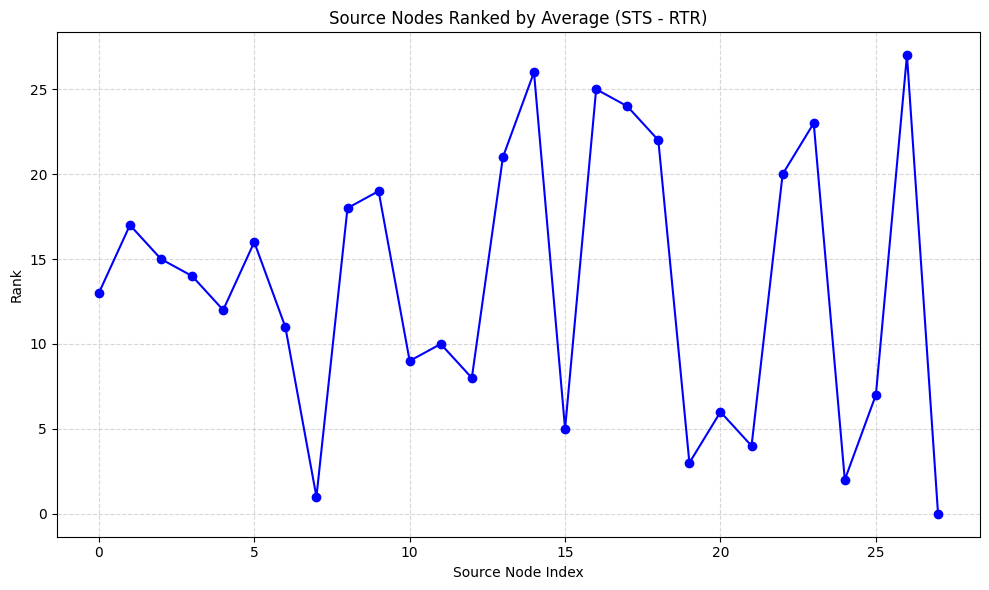

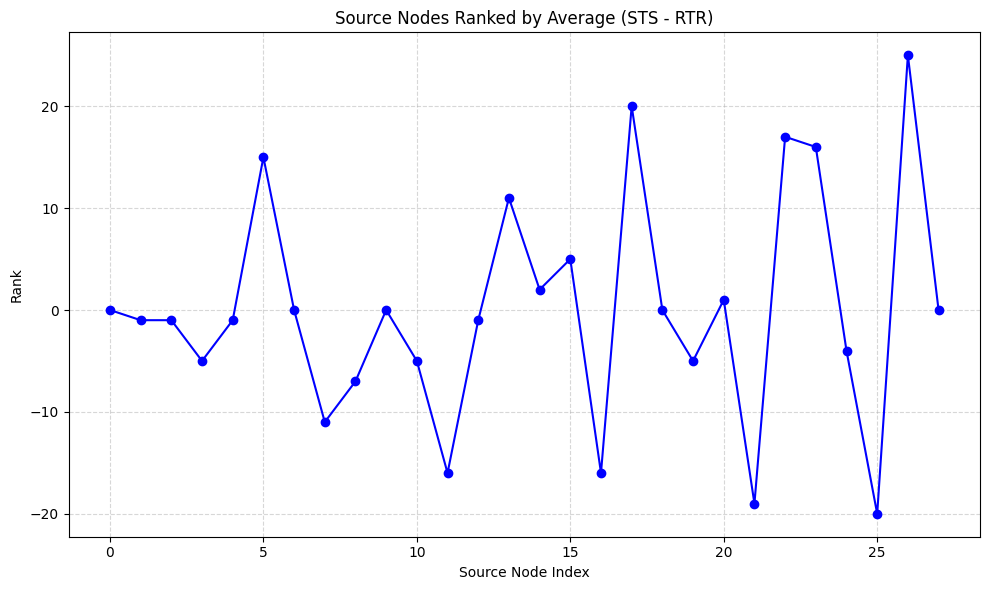

In [ ]:
phyid.plot_syn_minus_red_rank("syn_minus_red_rank")
phyid.syn_rank_minus_red_rank
phyid.plot_syn_minus_red_rank("syn_rank_minus_red_rank")

In [ ]:
plot_dir = cfg.paths.plot_phyid_dir
# plot_dir = None
phyid.node_heatmap(atom='sts', plot_dir=plot_dir)
phyid.plot_mean_along('sts', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('rtr', varying_dim='source_layer', plot_dir=plot_dir)
# phyid.plot_mean_along('mutual_information', varying_dim='source_layer', plot_dir=plot_dir)

Heatmap saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/alibaba/qwen-3/1.7B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/node_heatmap/sts/heatmap.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/alibaba/qwen-3/1.7B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/sts/source_layer.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/alibaba/qwen-3/1.7B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/rtr/source_layer.png


### Graph Theoretical Analysis

In [ ]:
from src.graph_theoretical_analysis import PromptGraphTheoreticalAnalysis

graph_theoretical = PromptGraphTheoreticalAnalysis.from_phyid_data(prompt_phyid=phyid)

In [ ]:
# graph_theoretical.plot_atom_graph(atom='sts')
sge = graph_theoretical.global_efficiency(atom='sts')
smo = graph_theoretical.modularity(atom='sts')
rge = graph_theoretical.global_efficiency(atom='rtr')
rmo = graph_theoretical.modularity(atom='rtr')
print(f"STS Global Efficiency: {sge}, STS Modularity: {smo}")
print(f"RTR Global Efficiency: {rge}, RTR Modularity: {rmo}")

STS Global Efficiency: 0.06715075956839713, STS Modularity: 0.09361335774685686
RTR Global Efficiency: 0.011644470371268695, RTR Modularity: 0.21492599394262663


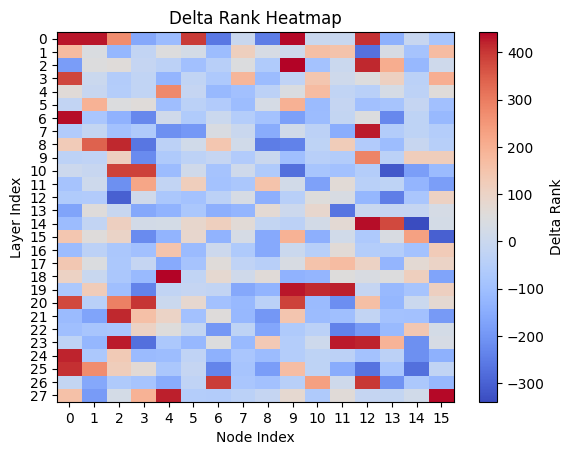

Gateways and Broadcasters: {'nodes': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 

In [ ]:
gb = graph_theoretical.gateways_and_broadcasters()
print(f"Gateways and Broadcasters: {gb}")